# Methodology 1 — Factors of Operational Delays
**Two-link chain:** operational factors (F, R, T) → Aggregated Delay → Aggregated NPS, inverted from the target NPS of 38 (= 0.38 on the −1…1 scale).


In [95]:
# ── Setup & reproducibility ─────────────────────────────────────────────
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED)
TARGET_NPS = 0.38            

df = pd.read_parquet("Data/final_data.parquet")
print(f"Passenger-level rows: {len(df):,}  |  unique services: {df['service_id'].nunique():,}")

Passenger-level rows: 169,480  |  unique services: 36,511


## 1. Unit of analysis — collapse to the service level

In [96]:
# ── Collapse to service level ───────────────────────────────────────────
service_level_cols = [
    'Aggregated Delay', 'Aggregated NPS', 'Departure Delay', 'Arrival Delay',
    'Theoretical Rotation Time', 'Effective Rotation Time', 'Exceeded Rotation Time',
    'fleet_reliability', 'total_fleet_reliability',
    'total_met_departures', 'total_ordered_departures',
    'n_trainsets', 'metadata_route', 'route_type', 'equipment_type', 'train_service'
]
service_level_cols = [c for c in service_level_cols if c in df.columns]

n_resp = df.groupby('service_id').size().rename('n_responses')
firsts = df.groupby('service_id')[service_level_cols].first()
svc = pd.concat([firsts, n_resp], axis=1).reset_index()


print(svc['n_responses'].describe())

count    36511.000000
mean         4.641889
std          2.820459
min          2.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         40.000000
Name: n_responses, dtype: float64


## 2. Outlier treatment

**Delays.** The boxplot of delays shows values above 6,000 minutes (> 4 days). A passenger service that actually ran cannot plausibly have departed 4 days late these records reflect cancellation/rebooking artefacts. The IQR rule with a 3× multiplier is used rather than the conventional 1.5× to capture the most severe delays A domain backstop of 600 minutes (10 hours) is applied on top as any above 10 hours is operationally implausible.

**Rotation times.** Rotations above ~12 hours are overnight stabling, not an operational turnaround buffer. Rotations are therefore restricted to ≤ 480 minutes (8 h).

Removed delay < -60 min: 8,702
3x IQR upper fence for Aggregated Delay: 251.9 min
Removed delay > 252 min: 201
Removed rotation outside (0, 480] min: 10,348

Final service-level sample: 17,260 (47.3% of service-level data retained)


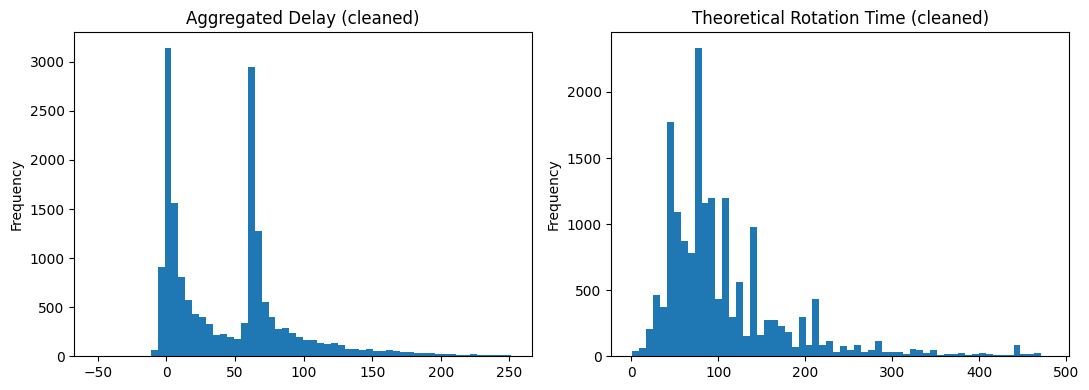

In [97]:
#Removing outliers based on IQR * 1.5 which is standard
def iqr_fence(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - k*(q3-q1), q3 + k*(q3-q1)

n0 = len(svc)

svc = svc[svc['Aggregated Delay'] >= -60]
n1 = len(svc); print(f"Removed delay < -60 min: {n0-n1:,}")

lo, hi = iqr_fence(svc['Aggregated Delay'], k=3.0)
print(f"3x IQR upper fence for Aggregated Delay: {hi:.1f} min")

DELAY_CAP = min(hi, 600.0)
svc = svc[svc['Aggregated Delay'] <= DELAY_CAP]
n2 = len(svc); print(f"Removed delay > {DELAY_CAP:.0f} min: {n1-n2:,}")

ROT_CAP = 480.0
svc = svc[(svc['Theoretical Rotation Time'] > 0) &
          (svc['Theoretical Rotation Time'] <= ROT_CAP)]
n3 = len(svc); print(f"Removed rotation outside (0, {ROT_CAP:.0f}] min: {n2-n3:,}")

print(f"\nFinal service-level sample: {n3:,} "
      f"({100*n3/n0:.1f}% of service-level data retained)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
svc['Aggregated Delay'].plot(kind='hist', bins=60, ax=ax[0], title='Aggregated Delay (cleaned)')
svc['Theoretical Rotation Time'].plot(kind='hist', bins=60, ax=ax[1], title='Theoretical Rotation Time (cleaned)')
plt.tight_layout(); plt.show()

## 3. Variable mapping for the operational levers

| Concept | Column used | Reasoning |
|---|---|---|
| **T — turnaround** | `Theoretical Rotation Time` | The scheduled buffer is the lever Eurostar controls when building the timetable. |
| **R — fleet reliability** | `total_fleet_reliability` | Day-level, fleet-wide met/ordered departure ratio. |
| **F — fleet availability** | `total_ordered_departures` | The number of departures the fleet was scheduled to cover that day bounded by the 51-unit fleet capacity. |

In [98]:
m = svc.rename(columns={
    'Aggregated Delay': 'agg_delay',
    'Aggregated NPS':   'agg_nps',
    'Theoretical Rotation Time': 'T',
    'total_fleet_reliability':   'R',
    'total_ordered_departures':  'F',
    'route_type': 'route',
}).copy()

chk = (m['F'] * m['R']) - svc['total_met_departures'].values
print(f"max |F x R - met_departures| = {np.nanmax(np.abs(chk)):.3f}  (≈0 confirms met = ordered x R)")

model_cols = ['agg_delay', 'agg_nps', 'F', 'R', 'T', 'route', 'n_responses']
m = m.dropna(subset=model_cols)
print(f"Complete-case modelling sample: {len(m):,} services")
print(m[['agg_delay','agg_nps','F','R','T','n_responses']].describe().T)

max |F x R - met_departures| = 0.002  (≈0 confirms met = ordered x R)
Complete-case modelling sample: 17,183 services
               count        mean        std      min     25%      50%    75%  \
agg_delay    17183.0   45.229779  45.411504 -51.9000   4.100  42.5000   66.1   
agg_nps      17183.0    0.267583   0.483688  -1.0000   0.000   0.3333    0.6   
F            17183.0   28.270907   2.654382  11.0000  27.000  28.0000   30.0   
R            17183.0    0.982382   0.038600   0.8148   0.963   1.0000    1.0   
T            17183.0  107.615841  74.290477   1.0000  61.000  85.0000  132.0   
n_responses  17183.0    4.292091   2.673575   2.0000   2.000   3.0000    5.0   

                  max  
agg_delay    251.4000  
agg_nps        1.0000  
F             34.0000  
R              1.1304  
T            479.0000  
n_responses   33.0000  


## 4. Aggregated Delay → Aggregated NPS (WLS)

**Specification.** `agg_nps = β₀ + β₁·agg_delay `, estimated by **Weighted Least Squares with wₛ = n_responsesₛ**.

In [99]:
Xb = sm.add_constant(m['agg_delay'])
yb = m['agg_nps']

ols_b = sm.OLS(yb, Xb).fit()
bp_stat, bp_p, _, _ = het_breuschpagan(
    ols_b.resid, sm.add_constant(m[['n_responses']]))
print(f"BP vs n_responses: LM = {bp_stat:.1f}, p = {bp_p:.2e}")
if bp_p < 0.05:
    print("-> Heteroscedasticity confirmed: residual variance depends on group size; WLS w = n_responses applied")
else:
    print("-> no significant evidence; WLS retained on a priori grounds (Var of a mean = sigma^2/n)")

linkB = sm.WLS(yb, Xb, weights=m['n_responses']).fit()
print(linkB.summary().tables[1])
b0, b1 = linkB.params['const'], linkB.params['agg_delay']


BP vs n_responses: LM = 508.8, p = 1.19e-112
-> Heteroscedasticity confirmed: residual variance depends on group size; WLS w = n_responses applied
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4284      0.005     85.522      0.000       0.419       0.438
agg_delay     -0.0030   6.82e-05    -44.104      0.000      -0.003      -0.003


## 4b. Functional form — is a linear satisfaction model appropriate?

The severity-band analysis in the second methodology shows that aggregated NPS does **not** fall monotonically with delay: it declines to a trough in the 30–60 minute band and then *recovers* beyond 60 minutes. A recovery is not a property of delay itself — longer delays do not make passengers happier — but of **compensation**, which Eurostar triggers at the higher delay thresholds and which returns goodwill on the most severely delayed services. The apparent non-linearity is therefore driven by a separate operational variable acting at high delays, not by the intrinsic delay→satisfaction relationship.

This has two consequences for the satisfaction model used in the inversion. First, fitting a globally flexible curve directly to delay→NPS would **absorb the compensation effect into the delay term**, mis-attributing "compensation recovers NPS" to "very long delays are less harmful than moderate ones", which is causally incorrect. Second, a non-monotonic curve would make the inversion **ill-posed**, since a single target NPS could correspond to more than one delay.

Crucially, the target of 0.38 lies near the punctual baseline (≈0.39–0.43) and is only attainable in the **low-delay region**, where the relationship is monotonic and approximately linear; the post-60-minute recovery only returns NPS to ≈0.26 and never approaches the target. The inversion therefore depends only on the locally linear region around the target, and the linear specification is the appropriate and invertible choice. The robustness check below confirms this by fitting flexible alternatives and showing that they agree with the linear model precisely where the inversion operates.

In [ ]:
# ── 4b. Robustness: flexible functional forms vs the linear satisfaction model ──
# Fit: (i) linear (the model used for inversion), (ii) quadratic, (iii) piecewise-linear
# with a knot at 30 min, and compare against the binned means and around the target.
import numpy as np
w = m['n_responses'].values
d = m['agg_delay'].values
y = m['agg_nps'].values

# (i) linear (already estimated as linkB)
lin = sm.WLS(y, sm.add_constant(d), weights=w).fit()

# (ii) quadratic
Xq = np.column_stack([d, d**2])
quad = sm.WLS(y, sm.add_constant(Xq), weights=w).fit()

# (iii) piecewise-linear, knot at 30 min (captures dip-then-recover without imposing it)
knot = 30.0
hinge = np.clip(d - knot, 0, None)
Xp = np.column_stack([d, hinge])
piece = sm.WLS(y, sm.add_constant(Xp), weights=w).fit()

# binned means for visual reference (same bands as Methodology 2)
edges = [-15,5,15,30,60,600]; labels=['≤5','5-15','15-30','30-60','60+']
m['_band'] = pd.cut(m['agg_delay'], bins=edges, labels=labels)
binned = (m.groupby('_band', observed=True)
            .apply(lambda g: np.average(g['agg_nps'], weights=g['n_responses']))
            .rename('wmean'))
band_mid = {'≤5':2.5,'5-15':10,'15-30':22.5,'30-60':45,'60+':90}

grid = np.linspace(0, 120, 200)
pred_lin   = lin.predict(sm.add_constant(grid))
pred_quad  = quad.predict(sm.add_constant(np.column_stack([grid, grid**2])))
pred_piece = piece.predict(sm.add_constant(np.column_stack([grid, np.clip(grid-knot,0,None)])))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter([band_mid[b] for b in binned.index], binned.values, s=70, color='#021F4B',
           zorder=5, label='Weighted band means (data)')
ax.plot(grid, pred_lin,   color='#C55A11', lw=2.2, label='Linear (used for inversion)')
ax.plot(grid, pred_quad,  color='#2E75B6', lw=1.8, ls='--', label='Quadratic')
ax.plot(grid, pred_piece, color='#2E7D32', lw=1.8, ls=':', label='Piecewise (knot=30)')
ax.axhline(TARGET_NPS, color='grey', lw=1, ls='-.'); ax.text(2,TARGET_NPS+.01,'target 0.38',fontsize=9,color='grey')
ax.axvspan(0, 20, color='#FFDD00', alpha=0.12)
ax.text(10, ax.get_ylim()[0]+0.02, 'inversion region', ha='center', fontsize=9, color='#8A6D00')
ax.set_xlabel('Aggregated delay (min)'); ax.set_ylabel('Aggregated NPS')
ax.set_title('Satisfaction model: functional-form robustness')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# inversion under each model, solved on the monotonic low-delay region [0, 30]
def invert(predict_fn, target, lo=0, hi=30):
    xs = np.linspace(lo, hi, 4000); ys = predict_fn(xs)
    i = np.argmin(np.abs(ys - target)); return xs[i]
dstar_lin   = (TARGET_NPS - lin.params[0])/lin.params[1]
dstar_quad  = invert(lambda x: quad.predict(sm.add_constant(np.column_stack([x,x**2]))), TARGET_NPS)
dstar_piece = invert(lambda x: piece.predict(sm.add_constant(np.column_stack([x,np.clip(x-knot,0,None)]))), TARGET_NPS)
print(f"Implied target delay (Delay*) under each functional form:")
print(f"  Linear     : {dstar_lin:5.1f} min   (the model used)")
print(f"  Quadratic  : {dstar_quad:5.1f} min")
print(f"  Piecewise  : {dstar_piece:5.1f} min")
print(f"\nThe three agree closely in the inversion region, confirming the linear")
print(f"specification is appropriate for the target; the dip-and-recover at high")
print(f"delays (compensation) lies far from 0.38 and does not affect the inversion.")

## 5. Evaluation — 5-fold cross-validation instead of a single split

**K-fold cross-validation** is used. (i) no observation is permanently sacrificed, (ii) the reported R²/RMSE is an average over five disjoint test sets and therefore far more stable, and (iii) the final model reported in the thesis is refit on all data. The fold split is done at the train service level, which automatically prevents leakage of passengers from the same service across folds

In [100]:
def weighted_r2(y, yhat, w):
    ybar = np.average(y, weights=w)
    ss_res = np.sum(w*(y-yhat)**2); ss_tot = np.sum(w*(y-ybar)**2)
    return 1 - ss_res/ss_tot

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
r2s, rmses = [], []
for tr, te in kf.split(m):
    tr_d, te_d = m.iloc[tr], m.iloc[te]
    fit = sm.WLS(tr_d['agg_nps'], sm.add_constant(tr_d['agg_delay']),
                 weights=tr_d['n_responses']).fit()
    pred = fit.predict(sm.add_constant(te_d['agg_delay']))
    r2s.append(weighted_r2(te_d['agg_nps'], pred, te_d['n_responses']))
    rmses.append(np.sqrt(np.average((te_d['agg_nps']-pred)**2,
                                    weights=te_d['n_responses'])))
print(f"Link B 5-fold CV:  weighted R2 = {np.mean(r2s):.4f} ± {np.std(r2s):.4f}"
      f"   |   weighted RMSE = {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")

Link B 5-fold CV:  weighted R2 = 0.1013 ± 0.0067   |   weighted RMSE = 0.4308 ± 0.0048


## 6. operational factors → Aggregated Delay (OLS, HC3)

**Specification.** `agg_delay = γ₀ + γ_F·F + γ_R·R + γ_T·T + γ_FR·(F×R) + route dummies`, with **HC3 heteroscedasticity-robust standard errors**.

In [101]:
linkA = smf.ols('agg_delay ~ F + R + T + F:R + C(route)', data=m).fit(cov_type='HC3')
print(linkA.summary().tables[1])

Xv = sm.add_constant(m[['F', 'R', 'T']])
vifs = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                 index=Xv.columns)
print("\nVIF:\n", vifs.round(2))

r2s = []
for tr, te in kf.split(m):
    fit = smf.ols('agg_delay ~ F + R + T + F:R + C(route)', data=m.iloc[tr]).fit()
    pred = fit.predict(m.iloc[te])
    ss_res = ((m.iloc[te]['agg_delay']-pred)**2).sum()
    ss_tot = ((m.iloc[te]['agg_delay']-m.iloc[te]['agg_delay'].mean())**2).sum()
    r2s.append(1-ss_res/ss_tot)
print(f"\nLink A 5-fold CV R2 = {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 217.4485     42.474      5.120      0.000     134.201     300.696
C(route)[T.Continental]   -58.7846      0.552   -106.399      0.000     -59.867     -57.702
F                          -5.3168      1.502     -3.540      0.000      -8.260      -2.373
R                        -146.3311     43.737     -3.346      0.001    -232.055     -60.607
T                          -0.0248      0.004     -6.043      0.000      -0.033      -0.017
F:R                         5.7239      1.550      3.693      0.000       2.686       8.762

VIF:
 const    824.94
F          1.01
R          1.01
T          1.00
dtype: float64

Link A 5-fold CV R2 = 0.4048 ± 0.0146


## 7. Inversion Step 1 

The linear Link B rearranges directly: **Delay\* = (0.38 − β₀) / β₁**. This is the maximum aggregated delay an average service can sustain while still achieving the target NPS.

In [102]:
delay_star = (TARGET_NPS - b0) / b1
print(f"Link B:  agg_nps = {b0:.4f} + ({b1:.6f}) * agg_delay")
print(f"Target delay for NPS = {TARGET_NPS}:  Delay* = {delay_star:.2f} minutes")

Link B:  agg_nps = 0.4284 + (-0.003009) * agg_delay
Target delay for NPS = 0.38:  Delay* = 16.09 minutes


## 8. Inversion Step 2 - 3D grid search over (F, R, T)

Three levers jointly determine one delay, so the solution is the feasibility frontier

In [103]:
ROUTE_FIX = m['route'].mode()[0]

NPS_LOW  = TARGET_NPS  # lower NPS bound (0.38 = the target)
NPS_HIGH = 0.38001       # upper NPS bound 

F_MIN = None       
F_MAX = None    
R_MIN = None   
R_MAX = None    
T_MIN = None    
T_MAX = None     

F_grid = np.arange(int(m['F'].quantile(.02)), int(m['F'].quantile(.98))+1, 1)
R_grid = np.round(np.arange(m['R'].quantile(.02), 1.0001, 0.01), 3)
T_grid = np.arange(int(m['T'].quantile(.02)), int(m['T'].quantile(.98))+1, 5)
print(f"Grid: {len(F_grid)} x {len(R_grid)} x {len(T_grid)} = "
      f"{len(F_grid)*len(R_grid)*len(T_grid):,} combinations")

FF, RR, TT = np.meshgrid(F_grid, R_grid, T_grid, indexing='ij')
grid = pd.DataFrame({'F': FF.ravel(), 'R': RR.ravel(), 'T': TT.ravel()})
grid['route'] = ROUTE_FIX

grid['pred_delay'] = linkA.predict(grid)
grid['pred_nps']   = b0 + b1*grid['pred_delay']

mask = (grid['pred_nps'] >= NPS_LOW) & (grid['pred_nps'] <= NPS_HIGH)
if F_MIN is not None: mask &= grid['F'] >= F_MIN
if F_MAX is not None: mask &= grid['F'] <= F_MAX
if R_MIN is not None: mask &= grid['R'] >= R_MIN
if R_MAX is not None: mask &= grid['R'] <= R_MAX
if T_MIN is not None: mask &= grid['T'] >= T_MIN
if T_MAX is not None: mask &= grid['T'] <= T_MAX

frontier = grid[mask].copy()
constraints_desc = f"F=[{F_MIN},{F_MAX}], R=[{R_MIN},{R_MAX}], T=[{T_MIN},{T_MAX}]"
print(f"Frontier computed for route: {ROUTE_FIX}")
print(f"NPS in [{NPS_LOW}, {NPS_HIGH}] | constraints: {constraints_desc}")
print(f"Matching configurations: {len(frontier):,}")
frontier.head(10)

Grid: 10 x 11 x 65 = 7,150 combinations
Frontier computed for route: Continental
NPS in [0.38, 0.38001] | constraints: F=[None,None], R=[None,None], T=[None,None]
Matching configurations: 3


,F,R,T,route,pred_delay,pred_nps
308,24,0.937,265,Continental,16.086949,0.380000
3434,28,0.977,295,Continental,16.085416,0.380005
6031,32,0.937,280,Continental,16.086170,0.380003


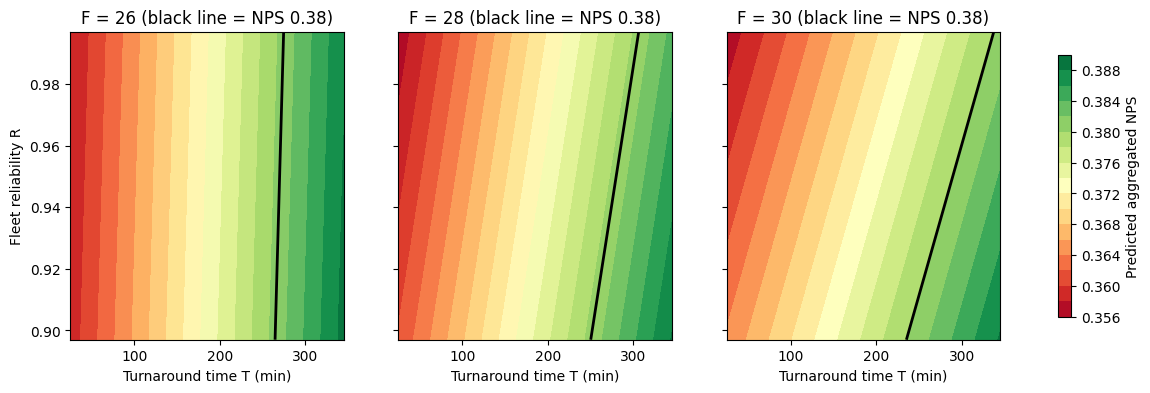

In [104]:
f_levels = np.quantile(F_grid, [0.25, 0.5, 0.75]).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, f in zip(axes, f_levels):
    sub = grid[grid['F'] == f].pivot(index='R', columns='T', values='pred_nps')
    cs = ax.contourf(sub.columns, sub.index, sub.values, levels=20, cmap='RdYlGn')
    ax.contour(sub.columns, sub.index, sub.values, levels=[TARGET_NPS],
               colors='k', linewidths=2)
    ax.set_title(f'F = {f} (black line = NPS {TARGET_NPS})')
    ax.set_xlabel('Turnaround time T (min)')
axes[0].set_ylabel('Fleet reliability R')
fig.colorbar(cs, ax=axes, shrink=0.85, label='Predicted aggregated NPS')
plt.show()

## 9. Chained marginal effects

By the chain rule through the two links: **∂NPS/∂x = β₁ × ∂Delay/∂x**, where ∂Delay/∂F = γ_F + γ_FR·R̄ and ∂Delay/∂R = γ_R + γ_FR·F̄ (the interaction makes each lever's effect depend on the level of the other), and ∂Delay/∂T = γ_T. Evaluated at current mean operating conditions, these rank the three levers by NPS gain per unit of improvement.

In [105]:
g = linkA.params
Fbar, Rbar = m['F'].mean(), m['R'].mean()
dD_dF = g['F'] + g['F:R']*Rbar
dD_dR = g['R'] + g['F:R']*Fbar
dD_dT = g['T']

marg = pd.DataFrame({
    'dDelay/dx (min)': [dD_dF, dD_dR, dD_dT],
    'dNPS/dx':         [b1*dD_dF, b1*dD_dR, b1*dD_dT],
}, index=['F (+1 ordered departure)', 'R (+1.00 i.e. per unit)', 'T (+1 min turnaround)'])
marg.loc['R (+0.01 i.e. +1pp)'] = marg.loc['R (+1.00 i.e. per unit)'] / 100
print(marg.round(5))

print(f"\nCurrent predicted NPS at mean operating point: "
      f"{b0 + b1*linkA.predict(pd.DataFrame({'F':[Fbar],'R':[Rbar],'T':[m['T'].mean()],'route':[ROUTE_FIX]}))[0]:.3f}"
      f"  vs target {TARGET_NPS}")

                          dDelay/dx (min)  dNPS/dx
F (+1 ordered departure)          0.30622 -0.00092
R (+1.00 i.e. per unit)          15.48835 -0.04660
T (+1 min turnaround)            -0.02483  0.00007
R (+0.01 i.e. +1pp)               0.15488 -0.00047

Current predicted NPS at mean operating point: 0.366  vs target 0.38
